# Chapter 27 — Self-Contained Consecutive-Timepoint Linking

In [1]:
!pip install -q zarr

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from scipy.spatial.distance import cdist
from skimage.feature import blob_log
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 91.6 MB/s eta 0:00:00


In [2]:
base = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
sample_id = "44b6_12dfb391"
zarr_path = base / "train" / f"{sample_id}.zarr"
geff_path = base / "train" / f"{sample_id}.geff"

if not base.exists():
    raise FileNotFoundError("Attach the Biohub competition data with Add Input.")

image = zarr.open(zarr_path, mode="r")["0"]
geff = zarr.open(geff_path, mode="r")

nodes_df = pd.DataFrame({
    "node_id": geff["nodes/ids"][:],
    "t": geff["nodes/props/t/values"][:],
    "z": geff["nodes/props/z/values"][:],
    "y": geff["nodes/props/y/values"][:],
    "x": geff["nodes/props/x/values"][:],
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
display(nodes_df.head())


Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


In [3]:
def first_existing_array(group, paths):
    for path in paths:
        try:
            return np.asarray(group[path][:]), path
        except Exception:
            pass
    return None, None

def load_geff_edges(group):
    source_paths = [
        "edges/source", "edges/sources", "edges/source_ids",
        "edges/props/source/values", "edges/props/source_id/values",
    ]
    target_paths = [
        "edges/target", "edges/targets", "edges/target_ids",
        "edges/props/target/values", "edges/props/target_id/values",
    ]

    sources, source_path = first_existing_array(group, source_paths)
    targets, target_path = first_existing_array(group, target_paths)

    if sources is not None and targets is not None:
        print("Source path:", source_path)
        print("Target path:", target_path)
        return pd.DataFrame({"source": sources, "target": targets})

    for path in ["edges/ids", "edges/index", "edges/indices", "edges/endpoints"]:
        try:
            arr = np.asarray(group[path][:])
            if arr.ndim == 2 and arr.shape[1] == 2:
                return pd.DataFrame(arr, columns=["source", "target"])
            if arr.ndim == 2 and arr.shape[0] == 2:
                return pd.DataFrame({"source": arr[0], "target": arr[1]})
        except Exception:
            pass

    raise KeyError("Could not identify GEFF edge arrays.")

edges_df = load_geff_edges(geff)

source_nodes = nodes_df.rename(columns={
    "node_id": "source", "t": "source_t",
    "z": "source_z", "y": "source_y", "x": "source_x",
})
target_nodes = nodes_df.rename(columns={
    "node_id": "target", "t": "target_t",
    "z": "target_z", "y": "target_y", "x": "target_x",
})

edge_detail_df = (
    edges_df.merge(source_nodes, on="source", how="left")
            .merge(target_nodes, on="target", how="left")
)
edge_detail_df["time_gap"] = edge_detail_df["target_t"] - edge_detail_df["source_t"]
edge_detail_df["movement_dist"] = np.sqrt(
    (edge_detail_df["target_z"] - edge_detail_df["source_z"])**2 +
    (edge_detail_df["target_y"] - edge_detail_df["source_y"])**2 +
    (edge_detail_df["target_x"] - edge_detail_df["source_x"])**2
)
consecutive_edges_df = edge_detail_df[edge_detail_df["time_gap"] == 1].copy()

print("GT edges:", len(edges_df))
print("Consecutive GT edges:", len(consecutive_edges_df))


GT edges: 773
Consecutive GT edges: 773


In [4]:
def pairwise_distances_3d(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=float)
    return cdist(a, b)

def extract_patch_3d(volume, z, y, x, rz=2, ryx=4):
    z0, z1 = max(0, z-rz), min(volume.shape[0], z+rz+1)
    y0, y1 = max(0, y-ryx), min(volume.shape[1], y+ryx+1)
    x0, x1 = max(0, x-ryx), min(volume.shape[2], x+ryx+1)
    return volume[z0:z1, y0:y1, x0:x1], (z0, z1, y0, y1, x0, x1)


In [5]:
def compute_2d_candidate_features(frame_3d, candidate_df, patch_radius=4):
    rows = []
    for _, r in candidate_df.iterrows():
        z, y, x = int(r.z), int(r.y), int(r.x)
        sigma = float(r.sigma)

        y0, y1 = max(0, y-patch_radius), min(frame_3d.shape[1], y+patch_radius+1)
        x0, x1 = max(0, x-patch_radius), min(frame_3d.shape[2], x+patch_radius+1)
        patch = frame_3d[z, y0:y1, x0:x1]
        if patch.size == 0:
            continue

        center_intensity = float(frame_3d[z, y, x])
        patch_mean, patch_max = float(patch.mean()), float(patch.max())
        patch_std = float(patch.std())
        local_contrast = patch_max - patch_mean

        peak_y, peak_x = np.unravel_index(np.argmax(patch), patch.shape)
        cy, cx = (patch.shape[0]-1)/2, (patch.shape[1]-1)/2
        center_to_patch_max_dist = float(np.hypot(peak_y-cy, peak_x-cx))

        yy, xx = np.indices(patch.shape)
        mass = patch.astype(float)
        if mass.sum() > 0:
            com_y = (yy*mass).sum()/mass.sum()
            com_x = (xx*mass).sum()/mass.sum()
            patch_com_offset = float(np.hypot(com_y-cy, com_x-cx))
        else:
            patch_com_offset = 0.0

        is_near_border = int(
            z <= 1 or z >= frame_3d.shape[0]-2 or
            y <= patch_radius or y >= frame_3d.shape[1]-patch_radius-1 or
            x <= patch_radius or x >= frame_3d.shape[2]-patch_radius-1
        )

        rows.append({
            "z": z, "y": y, "x": x, "sigma": sigma,
            "center_intensity": center_intensity,
            "patch_mean": patch_mean, "patch_max": patch_max,
            "patch_std": patch_std, "local_contrast": local_contrast,
            "center_to_patch_max_dist": center_to_patch_max_dist,
            "patch_com_offset": patch_com_offset,
            "is_near_border": is_near_border,
        })
    return pd.DataFrame(rows)


In [6]:
def compute_3d_candidate_features(frame_3d, candidate_df, rz=2, ryx=4):
    rows = []
    for _, r in candidate_df.iterrows():
        z, y, x = int(r.z), int(r.y), int(r.x)
        patch, bounds = extract_patch_3d(frame_3d, z, y, x, rz, ryx)
        z0, z1, y0, y1, x0, x1 = bounds
        if patch.size == 0:
            continue

        lz, ly, lx = z-z0, y-y0, x-x0
        center_voxel = float(patch[lz, ly, lx])
        vol_mean, vol_std, vol_max = float(patch.mean()), float(patch.std()), float(patch.max())

        z_line = patch[:, ly, lx]
        z_line_mean, z_line_std, z_line_max = float(z_line.mean()), float(z_line.std()), float(z_line.max())
        center_over_vol_mean = center_voxel/(vol_mean+1e-6)
        center_minus_vol_mean = center_voxel-vol_mean

        neighbors = []
        if lz-1 >= 0:
            neighbors.append(patch[lz-1])
        if lz+1 < patch.shape[0]:
            neighbors.append(patch[lz+1])
        neighbor_mean = float(np.mean([s.mean() for s in neighbors])) if neighbors else vol_mean
        center_slice_minus_neighbor_mean = float(patch[lz].mean()-neighbor_mean)
        slice_mean_std = float(np.std([s.mean() for s in patch]))

        peak_z, _, _ = np.unravel_index(np.argmax(patch), patch.shape)
        z_peak_offset = int(abs(peak_z-lz))

        zz, yy, xx = np.indices(patch.shape)
        mass = patch.astype(float)
        if mass.sum() > 0:
            com_z = (zz*mass).sum()/mass.sum()
            com_y = (yy*mass).sum()/mass.sum()
            com_x = (xx*mass).sum()/mass.sum()
            mass_center_offset_3d = float(np.sqrt(
                (com_z-lz)**2 + (com_y-ly)**2 + (com_x-lx)**2
            ))
        else:
            mass_center_offset_3d = 0.0

        rows.append({
            "z": z, "y": y, "x": x,
            "center_voxel": center_voxel,
            "vol_mean": vol_mean, "vol_std": vol_std, "vol_max": vol_max,
            "z_line_mean": z_line_mean, "z_line_std": z_line_std, "z_line_max": z_line_max,
            "center_over_vol_mean": center_over_vol_mean,
            "center_minus_vol_mean": center_minus_vol_mean,
            "center_slice_minus_neighbor_mean": center_slice_minus_neighbor_mean,
            "slice_mean_std": slice_mean_std,
            "z_peak_offset": z_peak_offset,
            "mass_center_offset_3d": mass_center_offset_3d,
            "peak_to_mean_ratio": vol_max/(vol_mean+1e-6),
            "bright_fraction": float((patch > vol_mean).mean()),
        })
    return pd.DataFrame(rows)


In [7]:
def detect_slice_wise_log(frame_3d, log_kwargs):
    rows = []
    for z in range(frame_3d.shape[0]):
        sl = frame_3d[z].astype(np.float32)
        mn, mx = float(sl.min()), float(sl.max())
        if mx <= mn:
            continue
        sl = (sl-mn)/(mx-mn)

        blobs = blob_log(
            sl,
            min_sigma=log_kwargs.get("min_sigma", 2.5),
            max_sigma=log_kwargs.get("max_sigma", 3.5),
            num_sigma=log_kwargs.get("num_sigma", 3),
            threshold=log_kwargs.get("threshold", 0.15),
        )

        for y, x, sigma in blobs:
            y = int(np.clip(round(y), 0, frame_3d.shape[1]-1))
            x = int(np.clip(round(x), 0, frame_3d.shape[2]-1))
            rows.append({
                "z": z, "y": y, "x": x, "sigma": float(sigma),
                "nms_score": float(frame_3d[z, y, x]),
            })

    if not rows:
        return pd.DataFrame(columns=["z","y","x","sigma","nms_score"])

    return pd.DataFrame(rows).drop_duplicates(["z","y","x"]).reset_index(drop=True)

def greedy_3d_nms(candidate_df, nms_radius=3.0):
    if len(candidate_df) == 0:
        return candidate_df.copy()

    work = candidate_df.sort_values("nms_score", ascending=False).reset_index(drop=True)
    kept = []

    while len(work):
        row = work.iloc[0].copy()
        kept.append(row)
        p = np.array([row.z, row.y, row.x], dtype=float)
        pts = work[["z","y","x"]].to_numpy(dtype=float)
        d = np.sqrt(((pts-p)**2).sum(axis=1))
        work = work[d > nms_radius].reset_index(drop=True)

    return pd.DataFrame(kept).reset_index(drop=True)

def build_candidate_feature_table(image, t, log_kwargs, nms_radius=3.0):
    frame = np.asarray(image[t])
    raw = detect_slice_wise_log(frame, log_kwargs)
    nms = greedy_3d_nms(raw, nms_radius)

    if len(nms) == 0:
        return pd.DataFrame(), frame, raw

    f2 = compute_2d_candidate_features(frame, nms[["z","y","x","sigma"]].copy())
    f3 = compute_3d_candidate_features(frame, nms[["z","y","x"]].copy())

    df = nms.merge(f2, on=["z","y","x"], how="left", suffixes=("","_2d"))
    df = df.merge(f3, on=["z","y","x"], how="left", suffixes=("","_3d"))
    df = df.drop(columns=["nms_score"], errors="ignore")
    df["t"] = t
    return df, frame, raw


In [8]:
train_timesteps = [0, 8, 20, 40]
oracle_radius = 6
nms_radius = 3.0
distance_clip = 20.0

log_kwargs = {
    "min_sigma": 2.5,
    "max_sigma": 3.5,
    "num_sigma": 3,
    "threshold": 0.15,
}

feature_cols = [
    "sigma","center_intensity","patch_mean","patch_max","patch_std",
    "local_contrast","center_to_patch_max_dist","patch_com_offset",
    "is_near_border","center_voxel","vol_mean","vol_std","vol_max",
    "z_line_mean","z_line_std","z_line_max","center_over_vol_mean",
    "center_minus_vol_mean","center_slice_minus_neighbor_mean",
    "slice_mean_std","z_peak_offset","mass_center_offset_3d",
    "peak_to_mean_ratio","bright_fraction",
]


In [9]:
train_tables = []

for t in train_timesteps:
    cand, frame, raw = build_candidate_feature_table(
        image, t, log_kwargs, nms_radius
    )

    if len(cand) == 0:
        continue

    gt = nodes_df[nodes_df["t"] == t]
    gt_pts = gt[["z","y","x"]].to_numpy(dtype=float)
    pred_pts = cand[["z","y","x"]].to_numpy(dtype=float)

    cand["nearest_gt_dist"] = (
        pairwise_distances_3d(gt_pts, pred_pts).min(axis=0)
        if len(gt_pts) else np.inf
    )
    cand["target_dist"] = cand["nearest_gt_dist"].clip(0, distance_clip)
    train_tables.append(cand)

    print(f"t={t}: raw={len(raw)}, nms={len(cand)}")

train_df = pd.concat(train_tables, ignore_index=True)

distance_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

distance_model.fit(
    train_df[feature_cols].fillna(0.0),
    train_df["target_dist"],
)

print("Training rows:", len(train_df))


t=0: raw=1541, nms=670
t=8: raw=1478, nms=661
t=20: raw=1653, nms=695
t=40: raw=1596, nms=688
Training rows: 2714


In [10]:
def run_final_candidate_detector(image, t, model, feature_cols, log_kwargs, nms_radius=3.0, top_k=200):
    cand, frame, raw = build_candidate_feature_table(
        image, t, log_kwargs, nms_radius
    )

    if len(cand) == 0:
        empty = pd.DataFrame(columns=[
            "t","node_id","rank_position","z","y","x","sigma","pred_dist"
        ])
        return {
            "raw_candidates": raw,
            "ranked_candidates": empty,
            "selected_candidates": empty.copy(),
            "frame_3d": frame,
        }

    ranked = cand.copy()
    ranked["pred_dist"] = model.predict(ranked[feature_cols].fillna(0.0))
    ranked = ranked.sort_values("pred_dist").reset_index(drop=True)
    ranked["rank_position"] = np.arange(1, len(ranked)+1)
    ranked["node_id"] = [f"pred_t{t}_{i}" for i in range(len(ranked))]

    return {
        "raw_candidates": raw,
        "ranked_candidates": ranked,
        "selected_candidates": ranked.head(min(top_k, len(ranked))).copy(),
        "frame_3d": frame,
    }


In [11]:
detection_timesteps = [60, 61, 80, 81]
top_k = 200

detector_outputs = {}
tables = []

for t in detection_timesteps:
    out = run_final_candidate_detector(
        image, t, distance_model, feature_cols,
        log_kwargs, nms_radius, top_k
    )
    detector_outputs[t] = out
    tables.append(out["selected_candidates"])
    print(
        f"t={t}: raw={len(out['raw_candidates'])}, "
        f"ranked={len(out['ranked_candidates'])}, "
        f"selected={len(out['selected_candidates'])}"
    )

ranked_detections_df = pd.concat(tables, ignore_index=True)

display(ranked_detections_df[
    ["t","node_id","rank_position","z","y","x","pred_dist"]
].head())


t=60: raw=1844, ranked=807, selected=200
t=61: raw=1881, ranked=817, selected=200
t=80: raw=1971, ranked=884, selected=200
t=81: raw=1926, ranked=866, selected=200


,t,node_id,rank_position,z,y,x,pred_dist
0,60,pred_t60_0,1,50.0,100.0,164.0,16.241658
1,60,pred_t60_1,2,50.0,10.0,163.0,16.376126
2,60,pred_t60_2,3,42.0,32.0,34.0,16.413093
3,60,pred_t60_3,4,44.0,6.0,206.0,16.723338
4,60,pred_t60_4,5,52.0,238.0,171.0,16.817365


In [12]:
def link_nearest_neighbors(source_df, target_df, max_movement=np.inf):
    if len(source_df) == 0 or len(target_df) == 0:
        return pd.DataFrame(columns=["source","target","distance","accepted"])

    s = source_df[["z","y","x"]].to_numpy(dtype=float)
    t = target_df[["z","y","x"]].to_numpy(dtype=float)
    dist = cdist(s, t)
    idx = dist.argmin(axis=1)
    d = dist[np.arange(len(source_df)), idx]

    out = pd.DataFrame({
        "source": source_df["node_id"].to_numpy(),
        "target": target_df.iloc[idx]["node_id"].to_numpy(),
        "distance": d,
    })
    out["accepted"] = out["distance"] <= max_movement
    return out

def link_greedy_one_to_one(source_df, target_df, max_movement=np.inf):
    if len(source_df) == 0 or len(target_df) == 0:
        return pd.DataFrame(columns=["source","target","distance"])

    s = source_df[["z","y","x"]].to_numpy(dtype=float)
    t = target_df[["z","y","x"]].to_numpy(dtype=float)
    dist = cdist(s, t)

    si, ti = np.indices(dist.shape)
    pairs = pd.DataFrame({
        "source_index": si.ravel(),
        "target_index": ti.ravel(),
        "distance": dist.ravel(),
    })
    pairs = pairs[pairs["distance"] <= max_movement].sort_values("distance")

    used_s, used_t, rows = set(), set(), []

    for _, r in pairs.iterrows():
        a, b = int(r.source_index), int(r.target_index)
        if a in used_s or b in used_t:
            continue
        used_s.add(a)
        used_t.add(b)
        rows.append({
            "source": source_df.iloc[a]["node_id"],
            "target": target_df.iloc[b]["node_id"],
            "distance": float(r.distance),
        })

    return pd.DataFrame(rows)


In [13]:
def evaluate_links(predicted_links_df, true_edges_df):
    pred = predicted_links_df.copy()
    if "accepted" in pred.columns:
        pred = pred[pred["accepted"]]

    pred_pairs = set(map(tuple, pred[["source","target"]].to_numpy()))
    true_pairs = set(map(tuple, true_edges_df[["source","target"]].to_numpy()))

    correct = pred_pairs & true_pairs

    return {
        "num_predicted_links": len(pred_pairs),
        "num_true_links": len(true_pairs),
        "num_correct_links": len(correct),
        "num_false_links": len(pred_pairs-true_pairs),
        "num_missed_links": len(true_pairs-pred_pairs),
        "link_precision": len(correct)/len(pred_pairs) if pred_pairs else np.nan,
        "link_recall": len(correct)/len(true_pairs) if true_pairs else np.nan,
    }


In [14]:
gt_frame_pairs = [(60,61), (80,81)]
movement_radii = [4,6,8,10,12,15]
rows = []

for source_t, target_t in gt_frame_pairs:
    source_gt = nodes_df[nodes_df["t"] == source_t].copy().reset_index(drop=True)
    target_gt = nodes_df[nodes_df["t"] == target_t].copy().reset_index(drop=True)
    true_edges = consecutive_edges_df[
        (consecutive_edges_df["source_t"] == source_t) &
        (consecutive_edges_df["target_t"] == target_t)
    ].copy()

    for radius in movement_radii:
        for method_name, linker in [
            ("nearest_neighbor", link_nearest_neighbors),
            ("greedy_one_to_one", link_greedy_one_to_one),
        ]:
            links = linker(source_gt, target_gt, radius)
            rows.append({
                "source_t": source_t,
                "target_t": target_t,
                "method": method_name,
                "radius": radius,
                **evaluate_links(links, true_edges),
            })

gt_link_results_df = pd.DataFrame(rows)
display(gt_link_results_df)


,source_t,target_t,method,radius,num_predicted_links,num_true_links,num_correct_links,num_false_links,num_missed_links,link_precision,link_recall
0,60,61,nearest_neighbor,4,9,9,9,0,0,1.0,1.0
1,60,61,greedy_one_to_one,4,9,9,9,0,0,1.0,1.0
2,60,61,nearest_neighbor,6,9,9,9,0,0,1.0,1.0
3,60,61,greedy_one_to_one,6,9,9,9,0,0,1.0,1.0
4,60,61,nearest_neighbor,8,9,9,9,0,0,1.0,1.0
5,60,61,greedy_one_to_one,8,9,9,9,0,0,1.0,1.0
6,60,61,nearest_neighbor,10,9,9,9,0,0,1.0,1.0
7,60,61,greedy_one_to_one,10,9,9,9,0,0,1.0,1.0
8,60,61,nearest_neighbor,12,9,9,9,0,0,1.0,1.0
9,60,61,greedy_one_to_one,12,9,9,9,0,0,1.0,1.0


In [15]:
average_gt_link_results_df = (
    gt_link_results_df
    .groupby(["method","radius"], as_index=False)
    .agg(
        mean_link_precision=("link_precision","mean"),
        mean_link_recall=("link_recall","mean"),
        total_correct_links=("num_correct_links","sum"),
    )
    .sort_values(
        ["mean_link_recall","mean_link_precision"],
        ascending=False,
    )
)

display(average_gt_link_results_df)


,method,radius,mean_link_precision,mean_link_recall,total_correct_links
1,greedy_one_to_one,6,1.0,1.0,14
2,greedy_one_to_one,8,1.0,1.0,14
3,greedy_one_to_one,10,1.0,1.0,14
4,greedy_one_to_one,12,1.0,1.0,14
5,greedy_one_to_one,15,1.0,1.0,14
7,nearest_neighbor,6,1.0,1.0,14
8,nearest_neighbor,8,1.0,1.0,14
9,nearest_neighbor,10,1.0,1.0,14
10,nearest_neighbor,12,1.0,1.0,14
11,nearest_neighbor,15,1.0,1.0,14


In [16]:
chosen_radius = 10.0
predicted_link_tables = []

for source_t, target_t in gt_frame_pairs:
    source_pred = ranked_detections_df[
        ranked_detections_df["t"] == source_t
    ].copy().reset_index(drop=True)

    target_pred = ranked_detections_df[
        ranked_detections_df["t"] == target_t
    ].copy().reset_index(drop=True)

    links = link_greedy_one_to_one(
        source_pred,
        target_pred,
        chosen_radius,
    )
    links["source_t"] = source_t
    links["target_t"] = target_t
    predicted_link_tables.append(links)

predicted_links_df = pd.concat(
    predicted_link_tables,
    ignore_index=True,
)

print("Predicted links:", len(predicted_links_df))
display(predicted_links_df.head())


Predicted links: 198


,source,target,distance,source_t,target_t
0,pred_t60_14,pred_t61_11,0.0,60,61
1,pred_t60_131,pred_t61_3,0.0,60,61
2,pred_t60_111,pred_t61_167,0.0,60,61
3,pred_t60_4,pred_t61_16,1.0,60,61
4,pred_t60_35,pred_t61_57,1.0,60,61


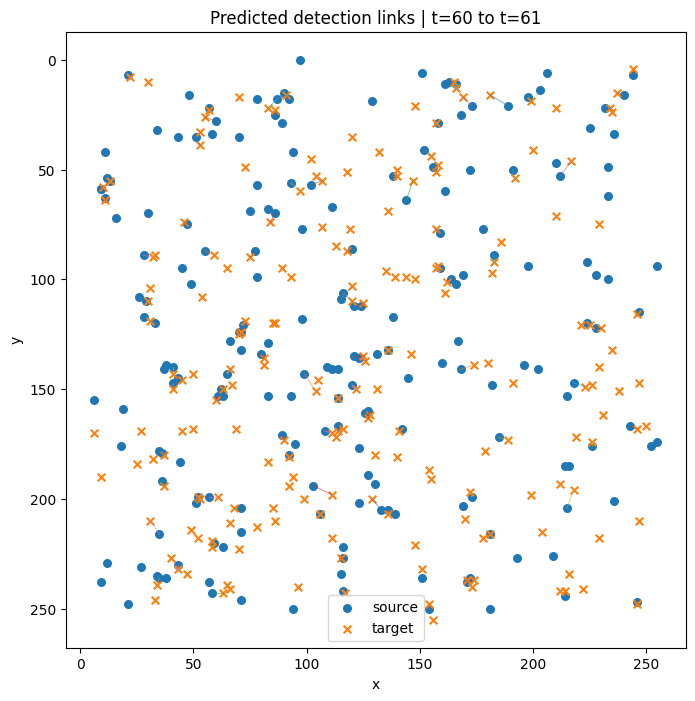

In [17]:
def plot_xy_links(source_df, target_df, links_df, title):
    source_lookup = source_df.set_index("node_id")
    target_lookup = target_df.set_index("node_id")

    plt.figure(figsize=(8,8))
    plt.scatter(source_df["x"], source_df["y"], s=30, label="source")
    plt.scatter(target_df["x"], target_df["y"], s=30, marker="x", label="target")

    for _, r in links_df.iterrows():
        if r.source not in source_lookup.index or r.target not in target_lookup.index:
            continue
        s = source_lookup.loc[r.source]
        t = target_lookup.loc[r.target]
        plt.plot([s.x,t.x], [s.y,t.y], linewidth=0.8, alpha=0.5)

    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

source_pred = ranked_detections_df[ranked_detections_df["t"] == 60].copy()
target_pred = ranked_detections_df[ranked_detections_df["t"] == 61].copy()
links_60_61 = predicted_links_df[
    (predicted_links_df["source_t"] == 60) &
    (predicted_links_df["target_t"] == 61)
].copy()

plot_xy_links(
    source_pred,
    target_pred,
    links_60_61,
    "Predicted detection links | t=60 to t=61",
)


In [18]:
ranked_output_path = "/kaggle/working/chapter27_ranked_detections.csv"
links_output_path = "/kaggle/working/chapter27_predicted_links.csv"

ranked_detections_df.to_csv(ranked_output_path, index=False)
predicted_links_df.to_csv(links_output_path, index=False)

print("Saved:", ranked_output_path)
print("Saved:", links_output_path)


Saved: /kaggle/working/chapter27_ranked_detections.csv
Saved: /kaggle/working/chapter27_predicted_links.csv
